<a href="https://colab.research.google.com/github/Luciana081/FitTrack/blob/main/ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric datasets tqdm -q

import re, torch, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torch.nn.functional as F
from tqdm import tqdm

print(" All imports ready!")
print("PyTorch:", torch.__version__)
print("Device:", "GPU " if torch.cuda.is_available() else "CPU ")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.1 MB/s eta 0:00:00
 All imports ready!
PyTorch: 2.10.0+cu128
Device: GPU 


In [ ]:
# ============ LOAD GRAPHS FROM DRIVE (run this instead of rebuilding) ============
from google.colab import drive
import pickle

drive.mount('/content/drive')

try:
    with open('/content/drive/MyDrive/fake_news_gnn/graphs.pkl', 'rb') as f:
        saved = pickle.load(f)
    train_graphs = saved['train']
    val_graphs   = saved['val']
    test_graphs  = saved['test']
    print(" Graphs loaded from Drive! Skipping rebuild.")
except:
    print("No saved graphs found — run the build cells below.")

Mounted at /content/drive
 Graphs loaded from Drive! Skipping rebuild.


In [ ]:
dataset = load_dataset("GonzaloA/fake_news")


train_df = pd.DataFrame(dataset['train']).dropna(subset=['text','label']).reset_index(drop=True)
val_df   = pd.DataFrame(dataset['validation']).dropna(subset=['text','label']).reset_index(drop=True)
test_df  = pd.DataFrame(dataset['test']).dropna(subset=['text','label']).reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Train: 24353 | Val: 8117 | Test: 8117
Label distribution:
label
1    13195
0    11158
Name: count, dtype: int64


In [ ]:
def text_to_graph(text, label):
    sentences = re.split(r'(?<=[.!?])\s+', str(text).strip())
    sentences = [s for s in sentences if len(s) > 10][:20]
    if len(sentences) < 2:
        sentences = [str(text)[:200]]
    num_nodes = len(sentences)
    node_features = []
    for i, sent in enumerate(sentences):
        words = sent.split()
        feat = [len(sent), len(words), i/num_nodes, sent.count('!'), sent.count('?')]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float)
    edge_src, edge_dst = [], []
    for i in range(num_nodes - 1):
        edge_src += [i, i+1]
        edge_dst += [i+1, i]
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    y = torch.tensor([int(label)], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

def build_dataset(df):
    graphs = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            g = text_to_graph(row['text'], row['label'])
            if g.num_nodes >= 2:
                graphs.append(g)
        except:
            pass
    print(f"Built {len(graphs)} graphs")
    return graphs

train_graphs = build_dataset(train_df)
val_graphs   = build_dataset(val_df)
test_graphs  = build_dataset(test_df)

100%|██████████| 24353/24353 [00:18<00:00, 1351.53it/s]


Built 22837 graphs


100%|██████████| 8117/8117 [00:05<00:00, 1515.85it/s]


Built 7601 graphs


100%|██████████| 8117/8117 [00:04<00:00, 1936.75it/s]

Built 7608 graphs


In [ ]:
# ============ SAVE GRAPHS TO DRIVE ============
from google.colab import drive
import pickle

drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/fake_news_gnn', exist_ok=True)

with open('/content/drive/MyDrive/fake_news_gnn/graphs.pkl', 'wb') as f:
    pickle.dump({
        'train': train_graphs,
        'val': val_graphs,
        'test': test_graphs
    }, f)

print("Graphs saved to Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graphs saved to Drive!


In [ ]:
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=32, shuffle=False)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Label balance
labels = [g.y.item() for g in train_graphs]
print(f"Fake: {sum(labels)} | Real: {len(labels)-sum(labels)}")

Train: 714 batches | Val: 238 | Test: 238
Fake: 12706 | Real: 10131


In [ ]:
class GCNFakeNews(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.classifier = torch.nn.Linear(hidden_channels // 2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_channels = train_graphs[0].x.shape[1]
gcn_model = GCNFakeNews(in_channels=in_channels, hidden_channels=128).to(device)
print(f"GCN ready | Device: {device} | Input features: {in_channels}")

GCN ready | Device: cuda | Input features: 5


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(dim=1) == batch.y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == batch.y).sum().item()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch.y.cpu().tolist())
    acc = correct / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1

print("Training functions ready!")

Training functions ready!


In [ ]:
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

gcn_train_accs, gcn_val_accs = [], []
best_val_acc = 0

print("Training GCN...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gcn_model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(gcn_model, val_loader, criterion)
    gcn_train_accs.append(train_acc)
    gcn_val_accs.append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(gcn_model.state_dict(), 'best_gcn.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

print(f"\n Best GCN Val Accuracy: {best_val_acc:.4f}")

Training GCN...

Epoch 05 | Loss: 0.6641 | Train: 0.6290 | Val: 0.6514 | F1: 0.6026
Epoch 10 | Loss: 0.4710 | Train: 0.7962 | Val: 0.7999 | F1: 0.7929
Epoch 15 | Loss: 0.4820 | Train: 0.7874 | Val: 0.8377 | F1: 0.8349
Epoch 20 | Loss: 0.4158 | Train: 0.8308 | Val: 0.8474 | F1: 0.8471
Epoch 25 | Loss: 0.4018 | Train: 0.8324 | Val: 0.8528 | F1: 0.8514
Epoch 30 | Loss: 0.4000 | Train: 0.8334 | Val: 0.8458 | F1: 0.8438
Epoch 35 | Loss: 0.4383 | Train: 0.8141 | Val: 0.8163 | F1: 0.8105
Epoch 40 | Loss: 0.3991 | Train: 0.8366 | Val: 0.8503 | F1: 0.8492
Epoch 45 | Loss: 0.4177 | Train: 0.8279 | Val: 0.8503 | F1: 0.8469
Epoch 50 | Loss: 0.3806 | Train: 0.8456 | Val: 0.8736 | F1: 0.8728

 Best GCN Val Accuracy: 0.8750


GCN Test Accuracy: 0.8755 | F1: 0.8752


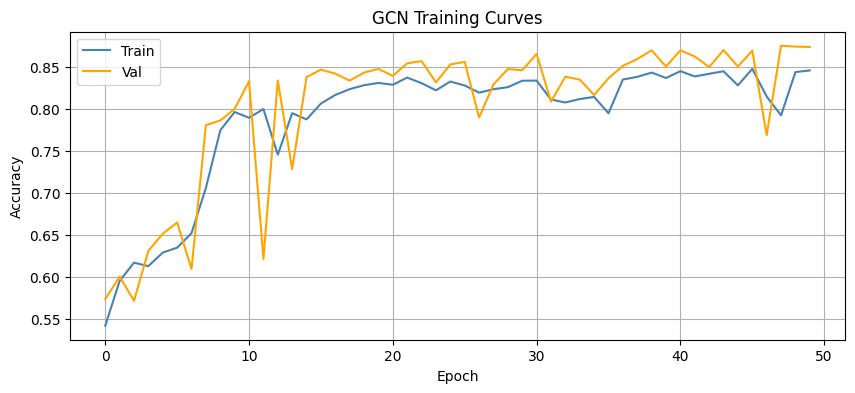

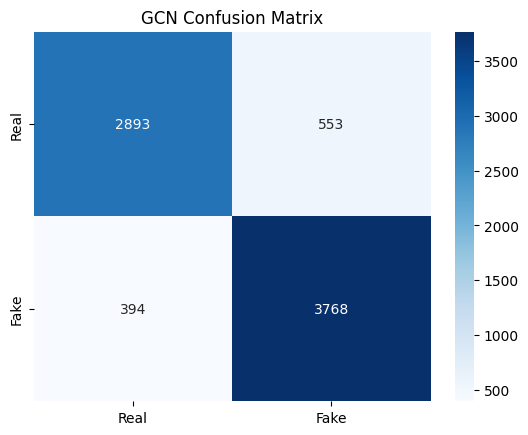

              precision    recall  f1-score   support

        Real       0.88      0.84      0.86      3446
        Fake       0.87      0.91      0.89      4162

    accuracy                           0.88      7608
   macro avg       0.88      0.87      0.87      7608
weighted avg       0.88      0.88      0.88      7608



In [ ]:
# Load best and test
gcn_model.load_state_dict(torch.load('best_gcn.pt'))
_, gcn_test_acc, gcn_test_f1 = evaluate(gcn_model, test_loader, criterion)
print(f"GCN Test Accuracy: {gcn_test_acc:.4f} | F1: {gcn_test_f1:.4f}")

# Training curve
plt.figure(figsize=(10,4))
plt.plot(gcn_train_accs, label='Train', color='steelblue')
plt.plot(gcn_val_accs, label='Val', color='orange')
plt.title('GCN Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.show()

# Confusion matrix
gcn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = gcn_model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('GCN Confusion Matrix'); plt.show()
print(classification_report(all_labels, all_preds, target_names=['Real','Fake']))

In [ ]:
#GAT model

In [ ]:
from torch_geometric.nn import GATConv, global_mean_pool

class GATFakeNews(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, heads=4, num_classes=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, dropout=dropout)
        self.conv3 = GATConv(hidden_channels, hidden_channels // 2, heads=1, dropout=dropout)
        self.classifier = torch.nn.Linear(hidden_channels // 2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

gat_model = GATFakeNews(in_channels=in_channels, hidden_channels=128, heads=4).to(device)
print(f"GAT ready | Input features: {in_channels}")
print(gat_model)

GAT ready | Input features: 5
GATFakeNews(
  (conv1): GATConv(5, 128, heads=4)
  (conv2): GATConv(512, 128, heads=1)
  (conv3): GATConv(128, 64, heads=1)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.001, weight_decay=5e-4)

gat_train_accs, gat_val_accs = [], []
best_gat_val_acc = 0

print("Training GAT...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gat_model, train_loader, gat_optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(gat_model, val_loader, criterion)
    gat_train_accs.append(train_acc)
    gat_val_accs.append(val_acc)
    if val_acc > best_gat_val_acc:
        best_gat_val_acc = val_acc
        torch.save(gat_model.state_dict(), 'best_gat.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

print(f"\n Best GAT Val Accuracy: {best_gat_val_acc:.4f}")

Training GAT...

Epoch 05 | Loss: 0.6842 | Train: 0.5721 | Val: 0.6141 | F1: 0.5353
Epoch 10 | Loss: 0.5396 | Train: 0.7402 | Val: 0.5843 | F1: 0.4622
Epoch 15 | Loss: 0.5022 | Train: 0.7792 | Val: 0.6128 | F1: 0.5194
Epoch 20 | Loss: 0.4898 | Train: 0.7960 | Val: 0.6696 | F1: 0.6167
Epoch 25 | Loss: 0.4036 | Train: 0.8336 | Val: 0.6623 | F1: 0.6031
Epoch 30 | Loss: 0.4303 | Train: 0.8346 | Val: 0.7149 | F1: 0.6821
Epoch 35 | Loss: 0.4038 | Train: 0.8357 | Val: 0.6481 | F1: 0.5802
Epoch 40 | Loss: 0.3904 | Train: 0.8431 | Val: 0.6393 | F1: 0.5634
Epoch 45 | Loss: 0.4280 | Train: 0.8302 | Val: 0.7219 | F1: 0.6918
Epoch 50 | Loss: 0.4067 | Train: 0.8420 | Val: 0.7311 | F1: 0.7050

 Best GAT Val Accuracy: 0.7794


GAT Test Accuracy: 0.7769 | F1: 0.7659


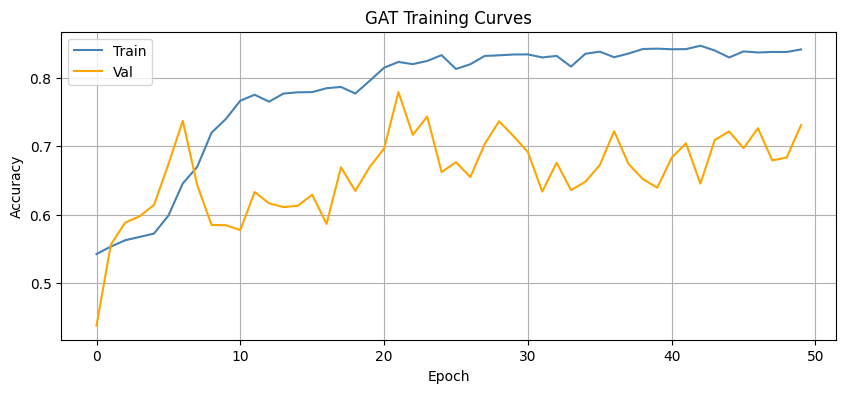

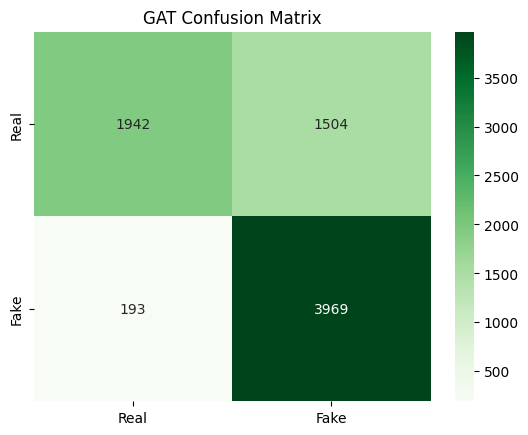

              precision    recall  f1-score   support

        Real       0.91      0.56      0.70      3446
        Fake       0.73      0.95      0.82      4162

    accuracy                           0.78      7608
   macro avg       0.82      0.76      0.76      7608
weighted avg       0.81      0.78      0.77      7608



In [ ]:
# Load best and test
gat_model.load_state_dict(torch.load('best_gat.pt'))
_, gat_test_acc, gat_test_f1 = evaluate(gat_model, test_loader, criterion)
print(f"GAT Test Accuracy: {gat_test_acc:.4f} | F1: {gat_test_f1:.4f}")

# Training curve
plt.figure(figsize=(10,4))
plt.plot(gat_train_accs, label='Train', color='steelblue')
plt.plot(gat_val_accs, label='Val', color='orange')
plt.title('GAT Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.show()

# Confusion matrix
gat_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = gat_model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('GAT Confusion Matrix'); plt.show()
print(classification_report(all_labels, all_preds, target_names=['Real','Fake']))

In [ ]:
from transformers import BertTokenizer, BertModel

# Load BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_encoder = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_encoder.eval()
print("BERT loaded!")

def get_bert_embedding(text):
    """Get 768-dim CLS embedding for a piece of text"""
    inputs = bert_tokenizer(
        str(text), return_tensors='pt',
        truncation=True, max_length=512, padding=True
    ).to(device)
    with torch.no_grad():
        outputs = bert_encoder(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze(0).cpu()

def text_to_bert_graph(text, label):
    """Same graph structure but root node uses BERT embedding"""
    sentences = re.split(r'(?<=[.!?])\s+', str(text).strip())
    sentences = [s for s in sentences if len(s) > 10][:20]
    if len(sentences) < 2:
        sentences = [str(text)[:200]]

    num_nodes = len(sentences)
    node_features = []

    for i, sent in enumerate(sentences):
        if i == 0:
            # Root node: use BERT embedding (768-dim)
            feat = get_bert_embedding(sent)
        else:
            # Other nodes: pad simple features to 768-dim
            words = sent.split()
            simple = [len(sent), len(words), i/num_nodes, sent.count('!'), sent.count('?')]
            feat = torch.zeros(768)
            feat[:5] = torch.tensor(simple, dtype=torch.float)
        node_features.append(feat)

    x = torch.stack(node_features)
    edge_src, edge_dst = [], []
    for i in range(num_nodes - 1):
        edge_src += [i, i+1]
        edge_dst += [i+1, i]
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    y = torch.tensor([int(label)], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

print("BERT graph builder ready!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded!
BERT graph builder ready!


In [ ]:
# Use a subset to keep it manageable (BERT is slow!)
# We use 5000 train, 1000 val, 1000 test samples
import random
random.seed(42)

def build_bert_dataset(df, max_samples=5000):
    graphs = []
    df_sample = df.sample(min(max_samples, len(df)), random_state=42).reset_index(drop=True)
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        try:
            g = text_to_bert_graph(row['text'], row['label'])
            if g.num_nodes >= 2:
                graphs.append(g)
        except:
            pass
    print(f"Built {len(graphs)} BERT graphs")
    return graphs

print("Building BERT train graphs (this will take ~10 min)...")
bert_train_graphs = build_bert_dataset(train_df, max_samples=5000)

print("Building BERT val graphs...")
bert_val_graphs = build_bert_dataset(val_df, max_samples=1000)

print("Building BERT test graphs...")
bert_test_graphs = build_bert_dataset(test_df, max_samples=1000)

# DataLoaders
bert_train_loader = DataLoader(bert_train_graphs, batch_size=16, shuffle=True)
bert_val_loader   = DataLoader(bert_val_graphs,   batch_size=16, shuffle=False)
bert_test_loader  = DataLoader(bert_test_graphs,  batch_size=16, shuffle=False)
print("BERT DataLoaders ready!")

Building BERT train graphs (this will take ~10 min)...


100%|██████████| 5000/5000 [00:53<00:00, 93.81it/s] 


Built 4692 BERT graphs
Building BERT val graphs...


100%|██████████| 1000/1000 [00:10<00:00, 94.12it/s]


Built 943 BERT graphs
Building BERT test graphs...


100%|██████████| 1000/1000 [00:10<00:00, 99.07it/s]

Built 955 BERT graphs
BERT DataLoaders ready!


In [ ]:
class BERTGCNFakeNews(torch.nn.Module):
    def __init__(self, bert_dim=768, hidden_channels=256, num_classes=2, dropout=0.5):
        super().__init__()
        # Project BERT 768-dim features down to hidden size
        self.input_proj = torch.nn.Linear(bert_dim, hidden_channels)
        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels // 2, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, num_classes)
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.input_proj(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

bert_gcn_model = BERTGCNFakeNews(bert_dim=768, hidden_channels=256).to(device)
print(f"BERT+GCN ready!")
print(bert_gcn_model)

BERT+GCN ready!
BERTGCNFakeNews(
  (input_proj): Linear(in_features=768, out_features=256, bias=True)
  (conv1): GCNConv(256, 256)
  (conv2): GCNConv(256, 256)
  (conv3): GCNConv(256, 128)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
bert_gcn_optimizer = torch.optim.Adam(bert_gcn_model.parameters(), lr=0.0005, weight_decay=5e-4)

bert_train_accs, bert_val_accs = [], []
best_bert_val_acc = 0

print("Training BERT+GCN...\n")
for epoch in range(1, 31):  # 30 epochs since dataset is smaller
    train_loss, train_acc = train_epoch(bert_gcn_model, bert_train_loader, bert_gcn_optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(bert_gcn_model, bert_val_loader, criterion)
    bert_train_accs.append(train_acc)
    bert_val_accs.append(val_acc)
    if val_acc > best_bert_val_acc:
        best_bert_val_acc = val_acc
        torch.save(bert_gcn_model.state_dict(), 'best_bert_gcn.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

print(f"\n Best BERT+GCN Val Accuracy: {best_bert_val_acc:.4f}")

Training BERT+GCN...

Epoch 05 | Loss: 0.0420 | Train: 0.9938 | Val: 0.9936 | F1: 0.9936
Epoch 10 | Loss: 0.0188 | Train: 0.9968 | Val: 0.9968 | F1: 0.9968
Epoch 15 | Loss: 0.0201 | Train: 0.9955 | Val: 0.9968 | F1: 0.9968
Epoch 20 | Loss: 0.0153 | Train: 0.9977 | Val: 0.9958 | F1: 0.9958
Epoch 25 | Loss: 0.0175 | Train: 0.9977 | Val: 0.9968 | F1: 0.9968
Epoch 30 | Loss: 0.0242 | Train: 0.9949 | Val: 0.9968 | F1: 0.9968

 Best BERT+GCN Val Accuracy: 0.9979


BERT+GCN Test Accuracy: 0.9969 | F1: 0.9969


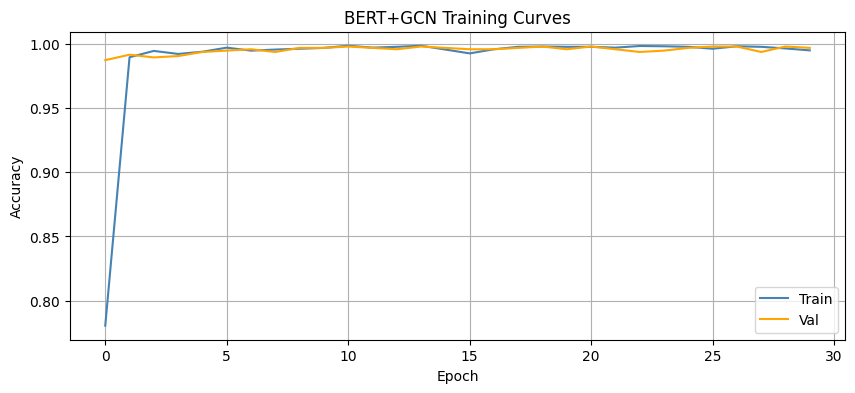

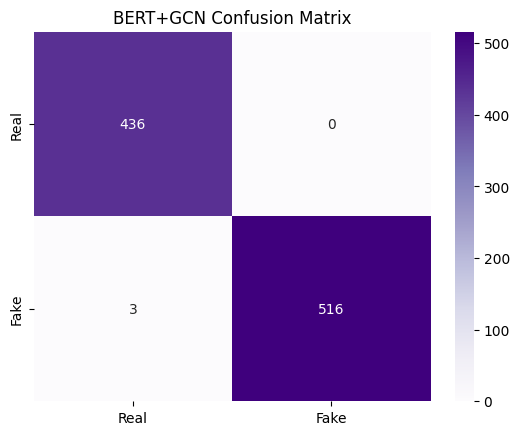

              precision    recall  f1-score   support

        Real       0.99      1.00      1.00       436
        Fake       1.00      0.99      1.00       519

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [ ]:
bert_gcn_model.load_state_dict(torch.load('best_bert_gcn.pt'))
_, bert_test_acc, bert_test_f1 = evaluate(bert_gcn_model, bert_test_loader, criterion)
print(f"BERT+GCN Test Accuracy: {bert_test_acc:.4f} | F1: {bert_test_f1:.4f}")

# Training curve
plt.figure(figsize=(10,4))
plt.plot(bert_train_accs, label='Train', color='steelblue')
plt.plot(bert_val_accs, label='Val', color='orange')
plt.title('BERT+GCN Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.show()

# Confusion matrix
bert_gcn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in bert_test_loader:
        batch = batch.to(device)
        out = bert_gcn_model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('BERT+GCN Confusion Matrix'); plt.show()
print(classification_report(all_labels, all_preds, target_names=['Real','Fake']))

       FINAL MODEL COMPARISON
Model             Test Acc    Test F1
--------------------------------------------------
GCN                 0.8755     0.8752
GAT                 0.7769     0.7659
BERT+GCN            0.9969     0.9969


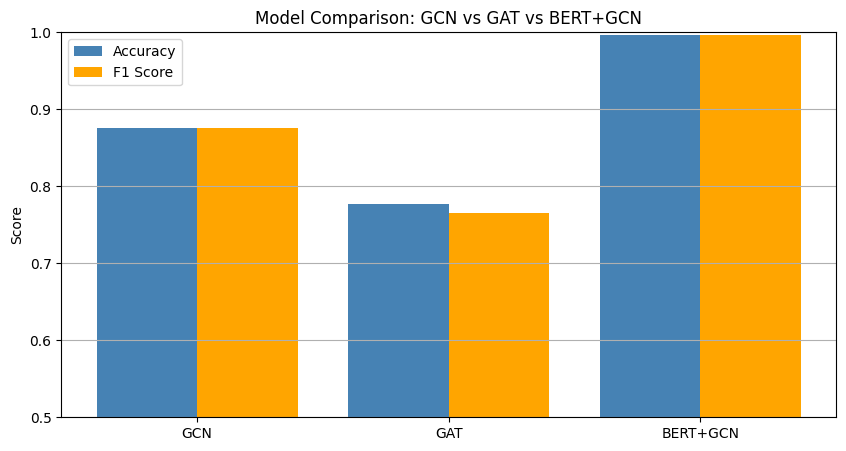

In [ ]:
print("=" * 50)
print("       FINAL MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<15} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 50)
print(f"{'GCN':<15} {gcn_test_acc:>10.4f} {gcn_test_f1:>10.4f}")
print(f"{'GAT':<15} {gat_test_acc:>10.4f} {gat_test_f1:>10.4f}")
print(f"{'BERT+GCN':<15} {bert_test_acc:>10.4f} {bert_test_f1:>10.4f}")
print("=" * 50)

# Bar chart comparison
models = ['GCN', 'GAT', 'BERT+GCN']
accuracies = [gcn_test_acc, gat_test_acc, bert_test_acc]
f1_scores  = [gcn_test_f1, gat_test_f1, bert_test_f1]

x = range(len(models))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], accuracies, width=0.4, label='Accuracy', color='steelblue')
plt.bar([i + 0.2 for i in x], f1_scores,  width=0.4, label='F1 Score',  color='orange')
plt.xticks(x, models)
plt.ylim(0.5, 1.0)
plt.ylabel('Score')
plt.title('Model Comparison: GCN vs GAT vs BERT+GCN')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
# ============ DATASET 2 ============
raw2 = load_dataset("mrm8488/fake-news", split="train")
df2 = pd.DataFrame(raw2)
print("Columns:", df2.columns.tolist())
print("Size:", len(df2))
print("Labels:", df2['label'].unique())
print("\nSample:")
print(df2.iloc[0])

fake_news.csv:   0%|          | 0.00/111M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44898 [00:00<?, ? examples/s]

Columns: ['text', 'label']
Size: 44898
Labels: [1 0]

Sample:
text     The Trump administration has been getting abso...
label                                                    1
Name: 0, dtype: object


In [ ]:
# ============ DATASET 3 ============
raw3 = load_dataset("ErfanMoosaviMonazzah/fake-news-detection-dataset-English")
df3 = pd.DataFrame(raw3['train'])
print("Columns:", df3.columns.tolist())
print("Size:", len(df3))
print("Labels:", df3['label'].unique())
print("\nSample:")
print(df3.iloc[0])

README.md:   0%|          | 0.00/487 [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/78.4M [00:00<?, ?B/s]

validation.tsv:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8267 [00:00<?, ? examples/s]

Columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']
Size: 30000
Labels: [1 0]

Sample:
Unnamed: 0                                                 2619
title         Ex-CIA head says Trump remarks on Russia inter...
text          Former CIA director John Brennan on Friday cri...
subject                                            politicsNews
date                                             July 22, 2017 
label                                                         1
Name: 0, dtype: object


In [ ]:
# Check what dataset 2 looks like first
print("Dataset 2 columns:", df2.columns.tolist())
print("Labels:", df2['label'].unique())
print("Label type:", type(df2['label'].iloc[0]))

Dataset 2 columns: ['text', 'label']
Labels: [1 0]
Label type: <class 'numpy.int64'>


In [ ]:
# Check what dataset 2 looks like first
print("Dataset 2 columns:", df2.columns.tolist())
print("Labels:", df2['label'].unique())
print("Label type:", type(df2['label'].iloc[0]))

Dataset 2 columns: ['text', 'label']
Labels: [1 0]
Label type: <class 'numpy.int64'>


In [ ]:
# Check what dataset 3 looks like first
print("Dataset 3 columns:", df3.columns.tolist())
print("Labels:", df3['label'].unique())
print("Label type:", type(df3['label'].iloc[0]))

Dataset 3 columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']
Labels: [1 0]
Label type: <class 'numpy.int64'>


In [ ]:
# Dataset 2
train2_df = df2[['text', 'label']].dropna().reset_index(drop=True)

# Split Dataset 2 into train/val/test since it only has one split
from sklearn.model_selection import train_test_split

train2, temp2 = train_test_split(train2_df, test_size=0.3, random_state=42)
val2, test2   = train_test_split(temp2, test_size=0.5, random_state=42)

print("Dataset 2 — Train:", len(train2), "| Val:", len(val2), "| Test:", len(test2))
print("Labels:", train2['label'].value_counts().to_dict())

Dataset 2 — Train: 31428 | Val: 6735 | Test: 6735
Labels: {1: 16384, 0: 15044}


In [ ]:
# Dataset 3
train3_df = df3[['text', 'label']].dropna().reset_index(drop=True)

train3, temp3 = train_test_split(train3_df, test_size=0.3, random_state=42)
val3, test3   = train_test_split(temp3, test_size=0.5, random_state=42)

print("Dataset 3 — Train:", len(train3), "| Val:", len(val3), "| Test:", len(test3))
print("Labels:", train3['label'].value_counts().to_dict())

Dataset 3 — Train: 21000 | Val: 4500 | Test: 4500
Labels: {0: 10778, 1: 10222}


In [ ]:
print("Building Dataset 2 graphs...")
train2_graphs = build_dataset(train2)
val2_graphs   = build_dataset(val2)
test2_graphs  = build_dataset(test2)

print("\nBuilding Dataset 3 graphs...")
train3_graphs = build_dataset(train3)
val3_graphs   = build_dataset(val3)
test3_graphs  = build_dataset(test3)

Building Dataset 2 graphs...


100%|██████████| 31428/31428 [00:08<00:00, 3527.16it/s]


Built 30420 graphs


100%|██████████| 6735/6735 [00:02<00:00, 2588.89it/s]


Built 6507 graphs


...

Built 20587 graphs


100%|██████████| 4500/4500 [00:01<00:00, 3580.11it/s]


Built 4420 graphs


100%|██████████| 4500/4500 [00:01<00:00, 2895.25it/s]

Built 4410 graphs


In [ ]:
# Dataset 2 loaders
train2_loader = DataLoader(train2_graphs, batch_size=32, shuffle=True)
val2_loader   = DataLoader(val2_graphs,   batch_size=32, shuffle=False)
test2_loader  = DataLoader(test2_graphs,  batch_size=32, shuffle=False)

# Dataset 3 loaders
train3_loader = DataLoader(train3_graphs, batch_size=32, shuffle=True)
val3_loader   = DataLoader(val3_graphs,   batch_size=32, shuffle=False)
test3_loader  = DataLoader(test3_graphs,  batch_size=32, shuffle=False)

print("Dataset 2 loaders ready!")
print(f"  Train: {len(train2_loader)} | Val: {len(val2_loader)} | Test: {len(test2_loader)}")
print("Dataset 3 loaders ready!")
print(f"  Train: {len(train3_loader)} | Val: {len(val3_loader)} | Test: {len(test3_loader)}")

Dataset 2 loaders ready!
  Train: 951 | Val: 204 | Test: 203
Dataset 3 loaders ready!
  Train: 644 | Val: 139 | Test: 138


In [ ]:
# Reset GCN model for Dataset 2
gcn_model2 = GCNFakeNews(in_channels=in_channels, hidden_channels=128).to(device)
optimizer2 = torch.optim.Adam(gcn_model2.parameters(), lr=0.001, weight_decay=5e-4)

gcn2_train_accs, gcn2_val_accs = [], []
best_gcn2_val = 0

print("Training GCN on Dataset 2...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gcn_model2, train2_loader, optimizer2, criterion)
    val_loss, val_acc, val_f1 = evaluate(gcn_model2, val2_loader, criterion)
    gcn2_train_accs.append(train_acc)
    gcn2_val_accs.append(val_acc)
    if val_acc > best_gcn2_val:
        best_gcn2_val = val_acc
        torch.save(gcn_model2.state_dict(), 'best_gcn2.pt')
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

gcn_model2.load_state_dict(torch.load('best_gcn2.pt'))
_, gcn2_test_acc, gcn2_test_f1 = evaluate(gcn_model2, test2_loader, criterion)
print(f"\n GCN Dataset 2 — Test Acc: {gcn2_test_acc:.4f} | F1: {gcn2_test_f1:.4f}")

Training GCN on Dataset 2...

Epoch 10 | Loss: 0.3775 | Train: 0.8422 | Val: 0.8394 | F1: 0.8377
Epoch 20 | Loss: 0.3606 | Train: 0.8519 | Val: 0.8704 | F1: 0.8704
Epoch 30 | Loss: 0.3546 | Train: 0.8548 | Val: 0.8795 | F1: 0.8795
Epoch 40 | Loss: 0.3485 | Train: 0.8574 | Val: 0.8827 | F1: 0.8828
Epoch 50 | Loss: 0.3504 | Train: 0.8574 | Val: 0.8758 | F1: 0.8754

 GCN Dataset 2 — Test Acc: 0.8782 | F1: 0.8782


In [ ]:
gcn_model3 = GCNFakeNews(in_channels=in_channels, hidden_channels=128).to(device)
optimizer3 = torch.optim.Adam(gcn_model3.parameters(), lr=0.001, weight_decay=5e-4)

gcn3_train_accs, gcn3_val_accs = [], []
best_gcn3_val = 0

print("Training GCN on Dataset 3...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gcn_model3, train3_loader, optimizer3, criterion)
    val_loss, val_acc, val_f1 = evaluate(gcn_model3, val3_loader, criterion)
    gcn3_train_accs.append(train_acc)
    gcn3_val_accs.append(val_acc)
    if val_acc > best_gcn3_val:
        best_gcn3_val = val_acc
        torch.save(gcn_model3.state_dict(), 'best_gcn3.pt')
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

gcn_model3.load_state_dict(torch.load('best_gcn3.pt'))
_, gcn3_test_acc, gcn3_test_f1 = evaluate(gcn_model3, test3_loader, criterion)
print(f"\n GCN Dataset 3 — Test Acc: {gcn3_test_acc:.4f} | F1: {gcn3_test_f1:.4f}")

Training GCN on Dataset 3...

Epoch 10 | Loss: 0.3914 | Train: 0.8355 | Val: 0.8452 | F1: 0.8444
Epoch 20 | Loss: 0.3752 | Train: 0.8491 | Val: 0.8629 | F1: 0.8627
Epoch 30 | Loss: 0.3648 | Train: 0.8520 | Val: 0.8753 | F1: 0.8753
Epoch 40 | Loss: 0.3610 | Train: 0.8559 | Val: 0.8364 | F1: 0.8344
Epoch 50 | Loss: 0.3564 | Train: 0.8577 | Val: 0.8475 | F1: 0.8459

 GCN Dataset 3 — Test Acc: 0.8764 | F1: 0.8764


In [ ]:
gat_model2 = GATFakeNews(in_channels=in_channels, hidden_channels=128, heads=4).to(device)
gat_optimizer2 = torch.optim.Adam(gat_model2.parameters(), lr=0.001, weight_decay=5e-4)

best_gat2_val = 0

print("Training GAT on Dataset 2...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gat_model2, train2_loader, gat_optimizer2, criterion)
    val_loss, val_acc, val_f1 = evaluate(gat_model2, val2_loader, criterion)
    if val_acc > best_gat2_val:
        best_gat2_val = val_acc
        torch.save(gat_model2.state_dict(), 'best_gat2.pt')
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

gat_model2.load_state_dict(torch.load('best_gat2.pt'))
_, gat2_test_acc, gat2_test_f1 = evaluate(gat_model2, test2_loader, criterion)
print(f"\n GAT Dataset 2 — Test Acc: {gat2_test_acc:.4f} | F1: {gat2_test_f1:.4f}")

Training GAT on Dataset 2...

Epoch 10 | Loss: 0.4221 | Train: 0.8176 | Val: 0.6450 | F1: 0.6040
Epoch 20 | Loss: 0.3877 | Train: 0.8401 | Val: 0.6410 | F1: 0.5964
Epoch 30 | Loss: 0.3825 | Train: 0.8408 | Val: 0.6375 | F1: 0.5911
Epoch 40 | Loss: 0.3781 | Train: 0.8447 | Val: 0.6287 | F1: 0.5776
Epoch 50 | Loss: 0.3780 | Train: 0.8413 | Val: 0.7072 | F1: 0.6880

 GAT Dataset 2 — Test Acc: 0.7332 | F1: 0.7329


In [ ]:
gat_model3 = GATFakeNews(in_channels=in_channels, hidden_channels=128, heads=4).to(device)
gat_optimizer3 = torch.optim.Adam(gat_model3.parameters(), lr=0.001, weight_decay=5e-4)

best_gat3_val = 0

print("Training GAT on Dataset 3...\n")
for epoch in range(1, 51):
    train_loss, train_acc = train_epoch(gat_model3, train3_loader, gat_optimizer3, criterion)
    val_loss, val_acc, val_f1 = evaluate(gat_model3, val3_loader, criterion)
    if val_acc > best_gat3_val:
        best_gat3_val = val_acc
        torch.save(gat_model3.state_dict(), 'best_gat3.pt')
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

gat_model3.load_state_dict(torch.load('best_gat3.pt'))
_, gat3_test_acc, gat3_test_f1 = evaluate(gat_model3, test3_loader, criterion)
print(f"\n GAT Dataset 3 — Test Acc: {gat3_test_acc:.4f} | F1: {gat3_test_f1:.4f}")

Training GAT on Dataset 3...

Epoch 10 | Loss: 0.6098 | Train: 0.6774 | Val: 0.4964 | F1: 0.3390
Epoch 20 | Loss: 0.6233 | Train: 0.6527 | Val: 0.4891 | F1: 0.3228
Epoch 30 | Loss: 0.5613 | Train: 0.7201 | Val: 0.4878 | F1: 0.3198
Epoch 40 | Loss: 0.5571 | Train: 0.7269 | Val: 0.4880 | F1: 0.3203
Epoch 50 | Loss: 0.5480 | Train: 0.7342 | Val: 0.4885 | F1: 0.3213

 GAT Dataset 3 — Test Acc: 0.6803 | F1: 0.6732


In [ ]:
bert_train2 = build_bert_dataset(train2, max_samples=3000)
bert_val2   = build_bert_dataset(val2,   max_samples=500)
bert_test2  = build_bert_dataset(test2,  max_samples=500)

bert_train2_loader = DataLoader(bert_train2, batch_size=16, shuffle=True)
bert_val2_loader   = DataLoader(bert_val2,   batch_size=16, shuffle=False)
bert_test2_loader  = DataLoader(bert_test2,  batch_size=16, shuffle=False)

bert_gcn_model2 = BERTGCNFakeNews(bert_dim=768, hidden_channels=256).to(device)
bert_gcn_optimizer2 = torch.optim.Adam(bert_gcn_model2.parameters(), lr=0.0005, weight_decay=5e-4)

best_bert2_val = 0
print("Training BERT+GCN on Dataset 2...\n")
for epoch in range(1, 31):
    train_loss, train_acc = train_epoch(bert_gcn_model2, bert_train2_loader, bert_gcn_optimizer2, criterion)
    val_loss, val_acc, val_f1 = evaluate(bert_gcn_model2, bert_val2_loader, criterion)
    if val_acc > best_bert2_val:
        best_bert2_val = val_acc
        torch.save(bert_gcn_model2.state_dict(), 'best_bert_gcn2.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

bert_gcn_model2.load_state_dict(torch.load('best_bert_gcn2.pt'))
_, bert2_test_acc, bert2_test_f1 = evaluate(bert_gcn_model2, bert_test2_loader, criterion)
print(f"\n BERT+GCN Dataset 2 — Test Acc: {bert2_test_acc:.4f} | F1: {bert2_test_f1:.4f}")

100%|██████████| 3000/3000 [00:31<00:00, 94.76it/s]


Built 2900 BERT graphs


100%|██████████| 500/500 [00:04<00:00, 103.79it/s]


Built 484 BERT graphs


100%|██████████| 500/500 [00:05<00:00, 96.97it/s]


Built 480 BERT graphs
Training BERT+GCN on Dataset 2...

Epoch 05 | Loss: 0.0464 | Train: 0.9886 | Val: 1.0000 | F1: 1.0000
Epoch 10 | Loss: 0.0144 | Train: 0.9948 | Val: 0.9979 | F1: 0.9979
Epoch 15 | Loss: 0.0282 | Train: 0.9948 | Val: 0.9959 | F1: 0.9959
Epoch 20 | Loss: 0.0139 | Train: 0.9945 | Val: 1.0000 | F1: 1.0000
Epoch 25 | Loss: 0.0059 | Train: 0.9986 | Val: 0.9979 | F1: 0.9979
Epoch 30 | Loss: 0.0200 | Train: 0.9966 | Val: 0.9959 | F1: 0.9959

 BERT+GCN Dataset 2 — Test Acc: 0.9938 | F1: 0.9937


In [ ]:
bert_train3 = build_bert_dataset(train3, max_samples=3000)
bert_val3   = build_bert_dataset(val3,   max_samples=500)
bert_test3  = build_bert_dataset(test3,  max_samples=500)

bert_train3_loader = DataLoader(bert_train3, batch_size=16, shuffle=True)
bert_val3_loader   = DataLoader(bert_val3,   batch_size=16, shuffle=False)
bert_test3_loader  = DataLoader(bert_test3,  batch_size=16, shuffle=False)

bert_gcn_model3 = BERTGCNFakeNews(bert_dim=768, hidden_channels=256).to(device)
bert_gcn_optimizer3 = torch.optim.Adam(bert_gcn_model3.parameters(), lr=0.0005, weight_decay=5e-4)

best_bert3_val = 0
print("Training BERT+GCN on Dataset 3...\n")
for epoch in range(1, 31):
    train_loss, train_acc = train_epoch(bert_gcn_model3, bert_train3_loader, bert_gcn_optimizer3, criterion)
    val_loss, val_acc, val_f1 = evaluate(bert_gcn_model3, bert_val3_loader, criterion)
    if val_acc > best_bert3_val:
        best_bert3_val = val_acc
        torch.save(bert_gcn_model3.state_dict(), 'best_bert_gcn3.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}")

bert_gcn_model3.load_state_dict(torch.load('best_bert_gcn3.pt'))
_, bert3_test_acc, bert3_test_f1 = evaluate(bert_gcn_model3, bert_test3_loader, criterion)
print(f"\n BERT+GCN Dataset 3 — Test Acc: {bert3_test_acc:.4f} | F1: {bert3_test_f1:.4f}")

100%|██████████| 3000/3000 [00:30<00:00, 97.33it/s] 


Built 2954 BERT graphs


100%|██████████| 500/500 [00:05<00:00, 84.87it/s] 


Built 490 BERT graphs


100%|██████████| 500/500 [00:04<00:00, 103.29it/s]


Built 489 BERT graphs
Training BERT+GCN on Dataset 3...

Epoch 05 | Loss: 0.1657 | Train: 0.9401 | Val: 0.9469 | F1: 0.9469
Epoch 10 | Loss: 0.1220 | Train: 0.9590 | Val: 0.9490 | F1: 0.9490
Epoch 15 | Loss: 0.1011 | Train: 0.9692 | Val: 0.9531 | F1: 0.9530
Epoch 20 | Loss: 0.0786 | Train: 0.9736 | Val: 0.9388 | F1: 0.9387
Epoch 25 | Loss: 0.0878 | Train: 0.9705 | Val: 0.9347 | F1: 0.9347
Epoch 30 | Loss: 0.0814 | Train: 0.9749 | Val: 0.9551 | F1: 0.9551

 BERT+GCN Dataset 3 — Test Acc: 0.9571 | F1: 0.9570


         FULL RESULTS — ALL MODELS × ALL DATASETS
Model              Dataset 1    Dataset 2    Dataset 3
-----------------------------------------------------------------
GCN Acc               0.8755       0.8782       0.8764
GCN F1                0.8752       0.8782       0.8764
-----------------------------------------------------------------
GAT Acc               0.7769       0.7332       0.6803
GAT F1                0.7659       0.7329       0.6732
-----------------------------------------------------------------
BERT+GCN Acc          0.9969       0.9938       0.9571
BERT+GCN F1           0.9969       0.9937       0.9570


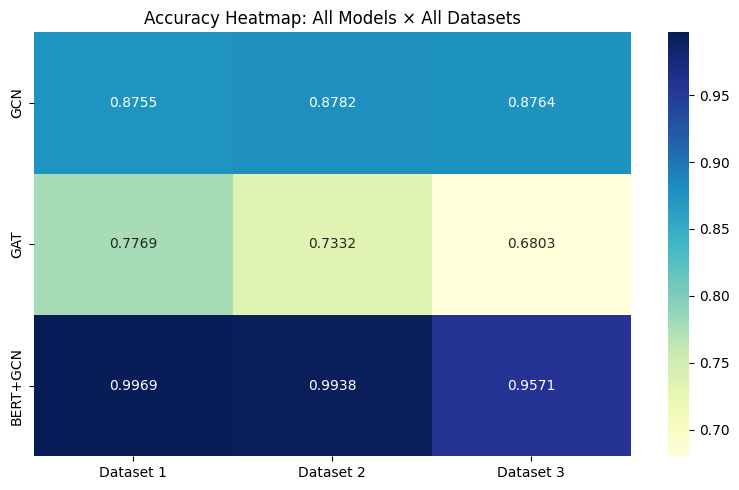

In [ ]:
print("=" * 65)
print("         FULL RESULTS — ALL MODELS × ALL DATASETS")
print("=" * 65)
print(f"{'Model':<15} {'Dataset 1':>12} {'Dataset 2':>12} {'Dataset 3':>12}")
print("-" * 65)
print(f"{'GCN Acc':<15} {gcn_test_acc:>12.4f} {gcn2_test_acc:>12.4f} {gcn3_test_acc:>12.4f}")
print(f"{'GCN F1':<15} {gcn_test_f1:>12.4f} {gcn2_test_f1:>12.4f} {gcn3_test_f1:>12.4f}")
print("-" * 65)
print(f"{'GAT Acc':<15} {gat_test_acc:>12.4f} {gat2_test_acc:>12.4f} {gat3_test_acc:>12.4f}")
print(f"{'GAT F1':<15} {gat_test_f1:>12.4f} {gat2_test_f1:>12.4f} {gat3_test_f1:>12.4f}")
print("-" * 65)
print(f"{'BERT+GCN Acc':<15} {bert_test_acc:>12.4f} {bert2_test_acc:>12.4f} {bert3_test_acc:>12.4f}")
print(f"{'BERT+GCN F1':<15} {bert_test_f1:>12.4f} {bert2_test_f1:>12.4f} {bert3_test_f1:>12.4f}")
print("=" * 65)

# Heatmap visualization
import numpy as np
results = np.array([
    [gcn_test_acc,  gcn2_test_acc,  gcn3_test_acc],
    [gat_test_acc,  gat2_test_acc,  gat3_test_acc],
    [bert_test_acc, bert2_test_acc, bert3_test_acc]
])

plt.figure(figsize=(8, 5))
sns.heatmap(results, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=['Dataset 1', 'Dataset 2', 'Dataset 3'],
            yticklabels=['GCN', 'GAT', 'BERT+GCN'])
plt.title('Accuracy Heatmap: All Models × All Datasets')
plt.tight_layout()
plt.show()

Training size experiment on Dataset 1...

Training size 20% (4567 graphs) → Test Acc: 0.8310
Training size 40% (9134 graphs) → Test Acc: 0.8368
Training size 60% (13702 graphs) → Test Acc: 0.8304
Training size 80% (18269 graphs) → Test Acc: 0.8160
Training size 100% (22837 graphs) → Test Acc: 0.7989


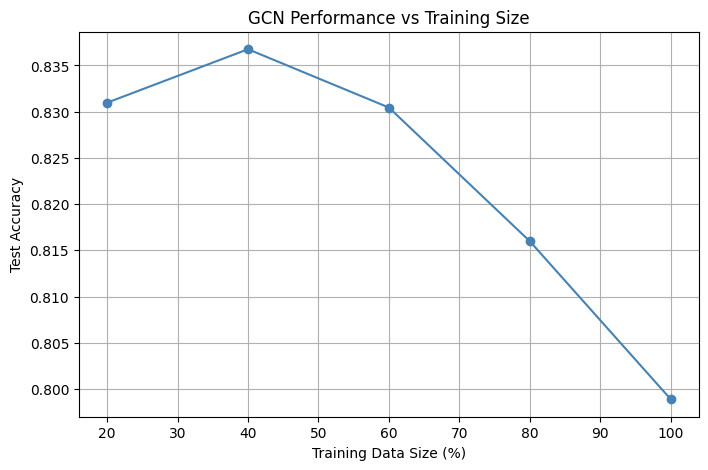

In [ ]:
# ============ EXPERIMENT 1: TRAINING SIZE ============
import numpy as np

sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
gcn_size_accs = []

print("Training size experiment on Dataset 1...\n")
for size in sizes:
    n = int(len(train_graphs) * size)
    subset = train_graphs[:n]
    loader = DataLoader(subset, batch_size=32, shuffle=True)

    temp_model = GCNFakeNews(in_channels=in_channels, hidden_channels=128).to(device)
    temp_opt = torch.optim.Adam(temp_model.parameters(), lr=0.001)

    for epoch in range(20):
        train_epoch(temp_model, loader, temp_opt, criterion)

    _, acc, _ = evaluate(temp_model, test_loader, criterion)
    gcn_size_accs.append(acc)
    print(f"Training size {int(size*100)}% ({n} graphs) → Test Acc: {acc:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot([int(s*100) for s in sizes], gcn_size_accs, marker='o', color='steelblue')
plt.xlabel('Training Data Size (%)')
plt.ylabel('Test Accuracy')
plt.title('GCN Performance vs Training Size')
plt.grid(True)
plt.show()

Hidden dimension experiment...

Hidden size 32 → Test Acc: 0.8056
Hidden size 64 → Test Acc: 0.8349
Hidden size 128 → Test Acc: 0.8478
Hidden size 256 → Test Acc: 0.8403


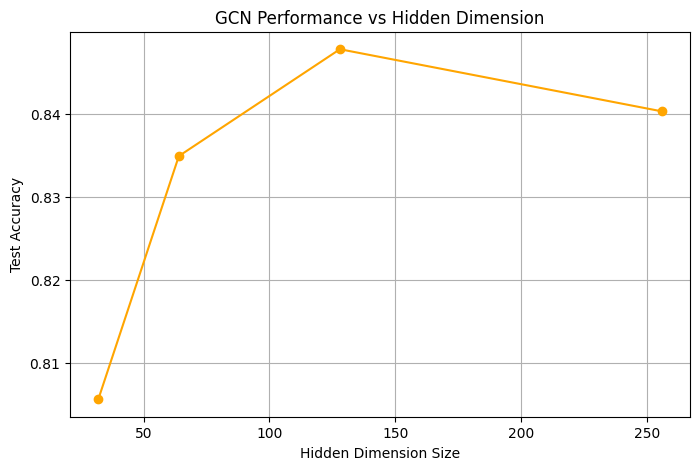

In [ ]:
# ============ EXPERIMENT 2: HIDDEN DIMENSIONS ============
hidden_sizes = [32, 64, 128, 256]
dim_accs = []

print("Hidden dimension experiment...\n")
for h in hidden_sizes:
    temp_model = GCNFakeNews(in_channels=in_channels, hidden_channels=h).to(device)
    temp_opt = torch.optim.Adam(temp_model.parameters(), lr=0.001)
    for epoch in range(20):
        train_epoch(temp_model, train_loader, temp_opt, criterion)
    _, acc, _ = evaluate(temp_model, test_loader, criterion)
    dim_accs.append(acc)
    print(f"Hidden size {h} → Test Acc: {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(hidden_sizes, dim_accs, marker='o', color='orange')
plt.xlabel('Hidden Dimension Size')
plt.ylabel('Test Accuracy')
plt.title('GCN Performance vs Hidden Dimension')
plt.grid(True)
plt.show()

Dropout experiment...

Dropout 0.1 → Test Acc: 0.8512
Dropout 0.3 → Test Acc: 0.8519
Dropout 0.5 → Test Acc: 0.8084
Dropout 0.7 → Test Acc: 0.8390


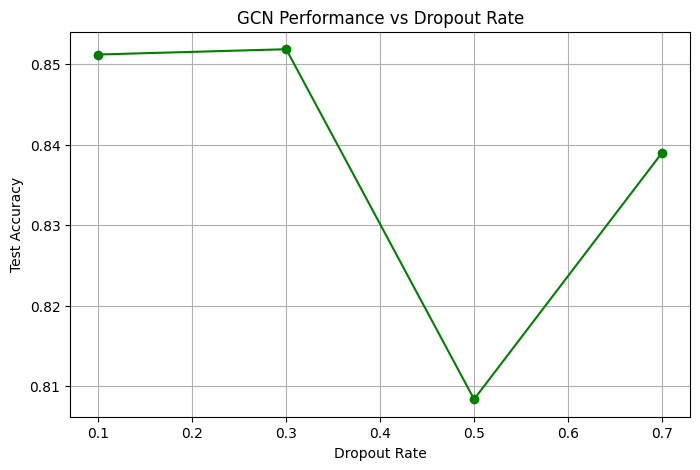

In [ ]:
# ============ EXPERIMENT 3: DROPOUT RATE ============
dropouts = [0.1, 0.3, 0.5, 0.7]
dropout_accs = []

print("Dropout experiment...\n")
for d in dropouts:
    temp_model = GCNFakeNews(in_channels=in_channels, hidden_channels=128, dropout=d).to(device)
    temp_opt = torch.optim.Adam(temp_model.parameters(), lr=0.001)
    for epoch in range(20):
        train_epoch(temp_model, train_loader, temp_opt, criterion)
    _, acc, _ = evaluate(temp_model, test_loader, criterion)
    dropout_accs.append(acc)
    print(f"Dropout {d} → Test Acc: {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(dropouts, dropout_accs, marker='o', color='green')
plt.xlabel('Dropout Rate')
plt.ylabel('Test Accuracy')
plt.title('GCN Performance vs Dropout Rate')
plt.grid(True)
plt.show()

In [ ]:
# ============ EXPERIMENT 4: GAT ATTENTION HEADS ============
head_counts = [1, 2, 4, 8]
head_accs = []

print("GAT attention heads experiment...\n")
for h in head_counts:
    temp_model = GATFakeNews(in_channels=in_channels, hidden_channels=128, heads=h).to(device)
    temp_opt = torch.optim.Adam(temp_model.parameters(), lr=0.001)
    for epoch in range(20):
        train_epoch(temp_model, train_loader, temp_opt, criterion)
    _, acc, _ = evaluate(temp_model, test_loader, criterion)
    head_accs.append(acc)
    print(f"Heads {h} → Test Acc: {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(head_counts, head_accs, marker='o', color='purple')
plt.xlabel('Number of Attention Heads')
plt.ylabel('Test Accuracy')
plt.title('GAT Performance vs Attention Heads')
plt.grid(True)
plt.show()

GAT attention heads experiment...



NameError: name 'GATFakeNews' is not defined